In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

In [2]:
import kagglehub
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os
from  glob import glob
from sklearn.model_selection import train_test_split
import keras
from keras.layers import Flatten, Dense,GRU, LSTM, RNN
from keras.models import Sequential
from sklearn.preprocessing import LabelEncoder ,  OneHotEncoder

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\1


In [4]:
blues = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\blues'
classic = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\classic'
country = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\country'
disco = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\disco'
hiphop = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\hiphop'
jazz = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\jazz'
metall = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\metall'
pop = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\pop'
reggae = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\reggae'
rock = r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\rock'

In [5]:
dataset_30sec = pd.read_csv(r'C:\Users\user\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\1\Data\features_30_sec.csv')

In [6]:
dataset_30sec

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,rock.00095.wav,661794,0.352063,0.080487,0.079486,0.000345,2008.149458,282174.689224,2106.541053,88609.749506,...,45.050526,-13.289984,41.754955,2.484145,36.778877,-6.713265,54.866825,-1.193787,49.950665,rock
996,rock.00096.wav,661794,0.398687,0.075086,0.076458,0.000588,2006.843354,182114.709510,2068.942009,82426.016726,...,33.851742,-10.848309,39.395096,1.881229,32.010040,-7.461491,39.196327,-2.795338,31.773624,rock
997,rock.00097.wav,661794,0.432142,0.075268,0.081651,0.000322,2077.526598,231657.968040,1927.293153,74717.124394,...,33.597008,-12.845291,36.367264,3.440978,36.001110,-12.588070,42.502201,-2.106337,29.865515,rock
998,rock.00098.wav,661794,0.362485,0.091506,0.083860,0.001211,1398.699344,240318.731073,1818.450280,109090.207161,...,46.324894,-4.416050,43.583942,1.556207,34.331261,-5.041897,47.227180,-3.590644,41.299088,rock


In [7]:
test = dataset_30sec.copy()

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
test['label'] = encoder.fit_transform(test['label'])

In [9]:
X = test.drop(['label', 'filename'], axis=1)  # Все столбцы кроме 'label' - это признаки
y = test['label']

In [10]:
classies = y.unique()

In [11]:
classies = encoder.fit_transform(classies)

In [12]:
print(y[:5]) 

0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.25, shuffle = True)

In [14]:
X_train.shape

(750, 58)

In [15]:
print(f"Размер X_train: {X_train.shape}")
print(f"Размер X_test: {X_test.shape}")
print(f"Количество уникальных классов в y_train: {len(np.unique(y_train))}")
print(f"Уникальные классы: {np.unique(y_train)}")
print(f"Распределение классов в y_train:\n{pd.Series(y_train).value_counts()}")
print(f"Распределение классов в y_test:\n{pd.Series(y_test).value_counts()}")
print(f"Тип данных X_train: {type(X_train)}")
print(f"Наличие NaN в X_train: {X_train.isna().any().any()}")
print(f"Диапазон значений в X_train: min={X_train.min().min():.4f}, max={X_train.max().max():.4f}")

Размер X_train: (750, 58)
Размер X_test: (250, 58)
Количество уникальных классов в y_train: 10
Уникальные классы: [0 1 2 3 4 5 6 7 8 9]
Распределение классов в y_train:
label
7    84
1    83
4    82
8    73
3    73
9    72
6    72
0    71
5    71
2    69
Name: count, dtype: int64
Распределение классов в y_test:
label
2    31
5    29
0    29
6    28
9    28
8    27
3    27
4    18
1    17
7    16
Name: count, dtype: int64
Тип данных X_train: <class 'pandas.core.frame.DataFrame'>
Наличие NaN в X_train: False
Диапазон значений в X_train: min=-552.1201, max=8660900.4844


In [17]:
from tensorflow import keras
from keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
target_names = [str(cls) for cls in np.unique(y_train)]

X_train_np = X_train.values
X_test_np = X_test.values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)


y_train_cat = to_categorical(y_train, num_classes=len(np.unique(y_train)))
y_test_cat = to_categorical(y_test, num_classes=len(np.unique(y_train)))

model_mlp = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(np.unique(y_train)), activation='softmax')
])

model_mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_mlp = model_mlp.fit(
    X_train_scaled, y_train_cat, 
    epochs=100, batch_size=32, 
    validation_data=(X_test_scaled, y_test_cat), 
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)

pred_mlp = model_mlp.predict(X_test_scaled)
pred_classes_mlp = np.argmax(pred_mlp, axis=1)
accuracy_mlp = accuracy_score(y_test, pred_classes_mlp)

print(f"Accuracy: {accuracy_mlp:.4f} ({accuracy_mlp*100:.2f}%)")


Epoch 1/100


C:\Users\user\Downloads\UDL Downloads\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1640 - loss: 2.3789 - val_accuracy: 0.2520 - val_loss: 2.1294
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2893 - loss: 1.9769 - val_accuracy: 0.3440 - val_loss: 1.9796
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3640 - loss: 1.7700 - val_accuracy: 0.4480 - val_loss: 1.8040
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4573 - loss: 1.5385 - val_accuracy: 0.4680 - val_loss: 1.6323
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5013 - loss: 1.3868 - val_accuracy: 0.5080 - val_loss: 1.5013
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5400 - loss: 1.3086 - val_accuracy: 0.5400 - val_loss: 1.3903
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5853 - loss: 1.1438 - val_accuracy: 0.5560 - val_loss: 1.3005
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6213 - loss: 1.1133 - val_accuracy: 0.5640 - val_loss: 1.

In [18]:
num_classes = len(np.unique(y_train))
print(f"Количество классов: {num_classes}")

Количество классов: 10


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
X_train_rnn = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_rnn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=0.00001,
    verbose=1
)

rnn_model = keras.Sequential([
    keras.layers.Input(shape=(1, X_train_scaled.shape[1])),
    keras.layers.SimpleRNN(64, return_sequences=False),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()

history_rnn = rnn_model.fit(
    X_train_rnn, y_train_cat,
    epochs=100, 
    batch_size=32,
    validation_data=(X_test_rnn, y_test_cat),
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

# Предсказания RNN
pred_rnn = rnn_model.predict(X_test_rnn)
pred_classes_rnn = np.argmax(pred_rnn, axis=1)
accuracy_rnn = accuracy_score(y_test, pred_classes_rnn)
print(f"Точность RNN: {accuracy_rnn:.4f} ({accuracy_rnn*100:.2f}%)")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 64)                  │           7,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,698 (57.41 KB)

 Trainable params: 14,570 (56.91 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1587 - loss: 2.5007 - val_accuracy: 0.2360 - val_loss: 2.1242 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3147 - loss: 1.9909 - val_accuracy: 0.3240 - val_loss: 1.9644 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3880 - loss: 1.7214 - val_accuracy: 0.3680 - val_loss: 1.8146 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4427 - loss: 1.5548 - val_accuracy: 0.4040 - val_loss: 1.6913 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4920 - loss: 1.4787 - val_accuracy: 0.4320 - val_loss: 1.5775 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5280 - loss: 1.3836 - val_accuracy: 0.4520 - val_loss: 1.4971 - learning_rate: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5293 - loss: 1.3200 - val_ac

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


# Оптимизированный Random Forest
rf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_train_scaled, y_train)
rf_pred = rf_best.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, rf_pred)
print(f"Точность Random Forest: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

Точность Random Forest: 0.7440 (74.40%)


In [25]:
X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))
simple_cnn = keras.Sequential([
   
    keras.layers.Input(shape=(X_train_scaled.shape[1], 1)),
    
    
    keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Dropout(0.25),
    
    
    keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Dropout(0.25),
    
    
    keras.layers.Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dropout(0.3),
    
    
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    
    
    keras.layers.Dense(num_classes, activation='softmax')
])


simple_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

simple_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 58, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 58, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 29, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 29, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 29, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 29, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 14, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 14, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 14, 256)             │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 14, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,626 (654.79 KB)

 Trainable params: 166,474 (650.29 KB)

 Non-trainable params: 1,152 (4.50 KB)

In [26]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=0.00001,
    verbose=1
)


history_simple_cnn = simple_cnn.fit(
    X_train_cnn, y_train_cat,
    epochs=150,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cat),
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

pred_simple_cnn = simple_cnn.predict(X_test_cnn)
pred_classes_simple_cnn = np.argmax(pred_simple_cnn, axis=1)
accuracy_simple_cnn = accuracy_score(y_test, pred_classes_simple_cnn)
print(f"Accuracy cnn: {accuracy_simple_cnn:.4f} ({accuracy_simple_cnn*100:.2f}%)")

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.2107 - loss: 2.4247 - val_accuracy: 0.1520 - val_loss: 2.2761 - learning_rate: 0.0010
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3013 - loss: 1.9991 - val_accuracy: 0.1520 - val_loss: 2.2490 - learning_rate: 0.0010
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3253 - loss: 1.9040 - val_accuracy: 0.1240 - val_loss: 2.2533 - learning_rate: 0.0010
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3627 - loss: 1.7517 - val_accuracy: 0.1600 - val_loss: 2.2788 - learning_rate: 0.0010
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3853 - loss: 1.7057 - val_accuracy: 0.1560 - val_loss: 2.3302 - learning_rate: 0.0010
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4333 - loss: 1.5984 - val_accuracy: 0.1360 - val_loss: 2.3582 - learning_rate: 0.0010
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4360 - loss: 1.5891 - 

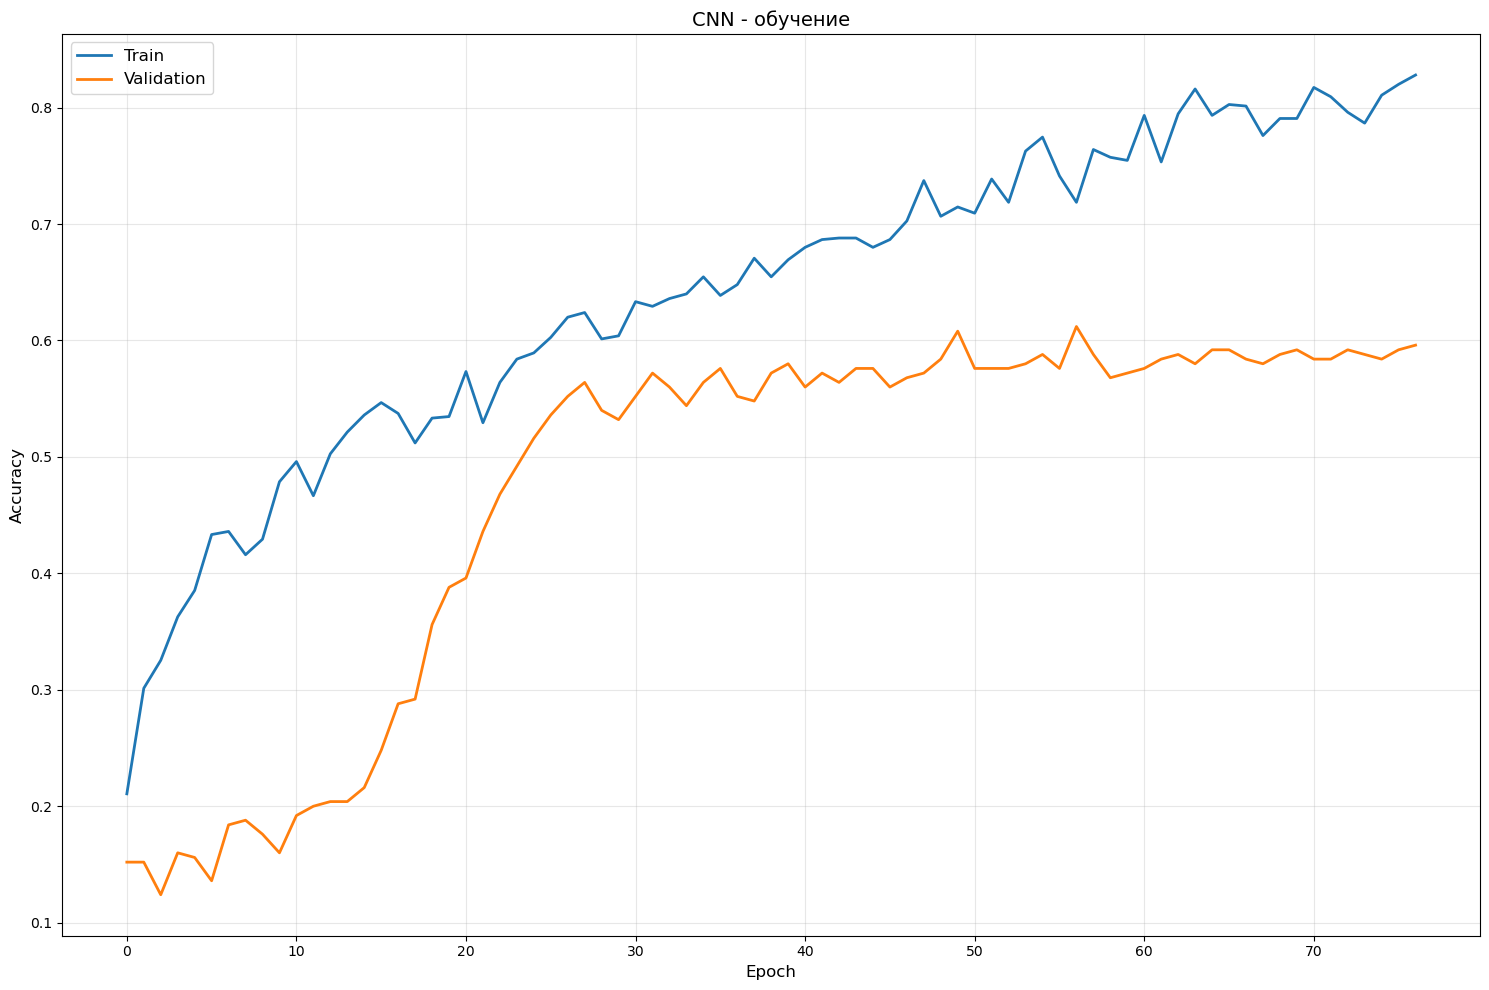

In [28]:
fig, ax = plt.subplots(1, figsize=(15, 10))  
ax.plot(history_simple_cnn.history['accuracy'], label='Train', linewidth=2)
ax.plot(history_simple_cnn.history['val_accuracy'], label='Validation', linewidth=2)
ax.set_title('CNN - обучение', fontsize=14)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

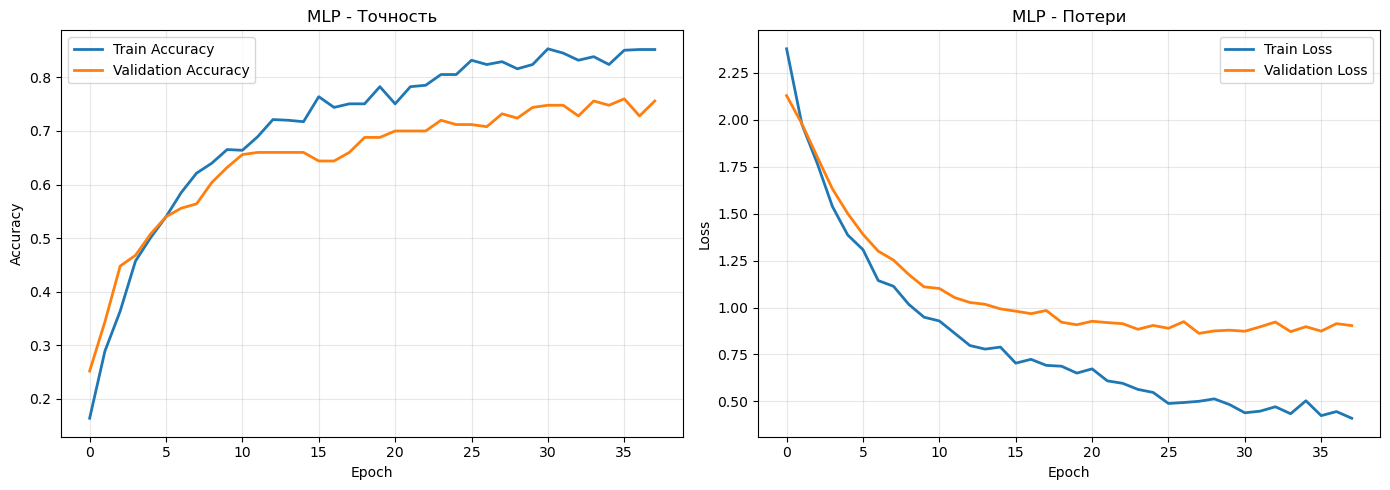

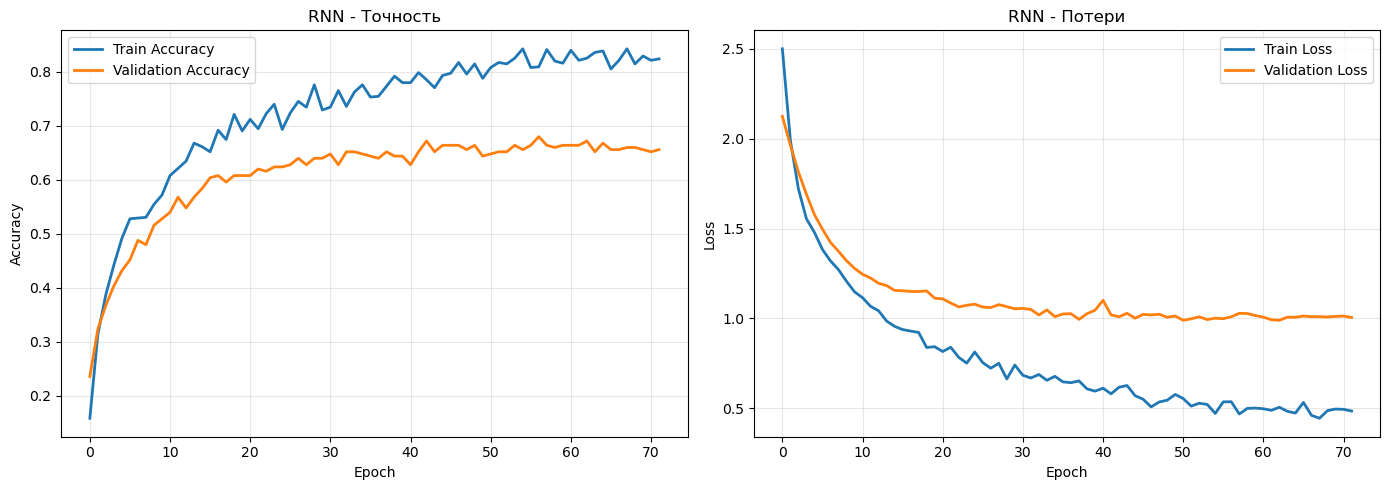

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(history_mlp.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_mlp.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('MLP - Точность', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].plot(history_mlp.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_mlp.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('MLP - Потери', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_rnn.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('RNN - Точность', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].plot(history_rnn.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_rnn.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('RNN - Потери', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
from tensorflow.keras import layers
from tensorflow.keras import backend as K

class AttentionLayer(layers.Layer):
    
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', 
                                 shape=(input_shape[-1], 1),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)
        super(AttentionLayer, self).build(input_shape)
    
    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        e = K.squeeze(e, axis=-1)
        alpha = K.softmax(e)
        alpha = K.expand_dims(alpha, axis=-1)
        output = x * alpha
        return K.sum(output, axis=1)
    
    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensorflow.keras import layers
from tensorflow.keras import backend as K

attention_layer = AttentionLayer()

np.random.seed(42)
sample_data = np.random.randn(10, 5, 8) 

def get_attention_weights(layer, x):
    W = layer.W.numpy()
    b = layer.b.numpy()
    
    e = np.tanh(np.dot(x, W) + b)
    e = np.squeeze(e, axis=-1)
    alpha = np.exp(e) / np.sum(np.exp(e), axis=1, keepdims=True)
    
    return alpha


_ = attention_layer(sample_data)


attention_weights = get_attention_weights(attention_layer, sample_data)

print(f"Форма входных данных: {sample_data.shape}")
print(f"Форма весов внимания: {attention_weights.shape}")

Визуализация Attention механизма
Форма входных данных: (10, 5, 8)
Форма весов внимания: (10, 5)


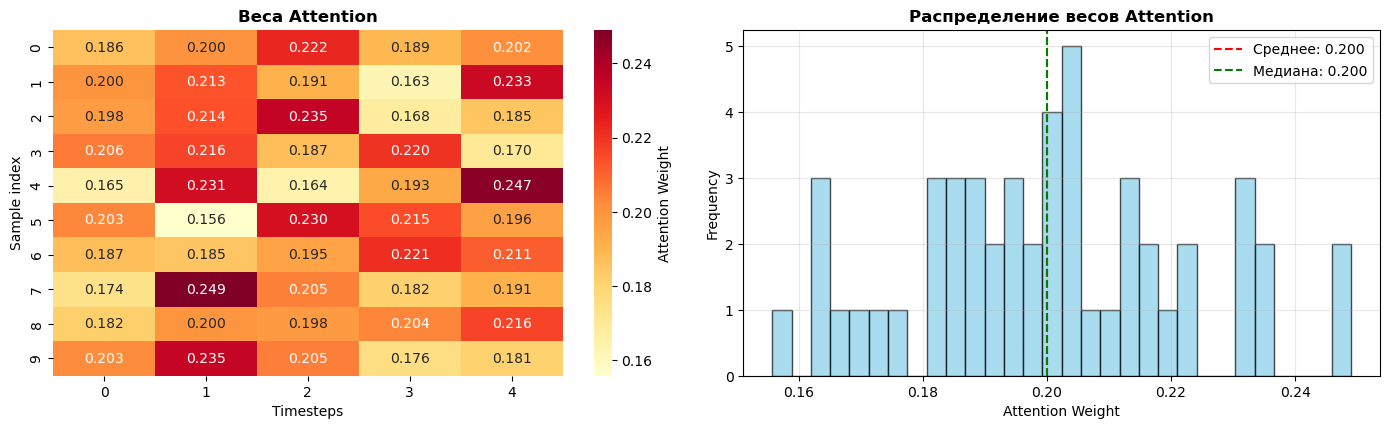

In [32]:
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
sns.heatmap(attention_weights, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Attention Weight'})
plt.title('Веса Attention', fontsize=12, fontweight='bold')
plt.xlabel('Timesteps', fontsize=10)
plt.ylabel('Sample index', fontsize=10)


plt.subplot(2, 2, 2)
plt.hist(attention_weights.flatten(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Attention Weight', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title('Распределение весов Attention', fontsize=12, fontweight='bold')
plt.axvline(np.mean(attention_weights), color='red', linestyle='--', label=f'Среднее: {np.mean(attention_weights):.3f}')
plt.axvline(np.median(attention_weights), color='green', linestyle='--', label=f'Медиана: {np.median(attention_weights):.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()